# 4.6 Autoencoders y aprendizaje autosupervisado

Un *autoencoder* (autocodificador) es una red neuronal entrenada para reproducir su propia entrada. Eso suena inútil hasta que se agrega una restricción: la red debe exprimir los datos a través de un **cuello de botella** estrecho antes de reconstruirlos. Para lograrlo, la red tiene que aprender una representación compacta que conserve la estructura de los datos y descarte el resto.

![Auto-encoder](../img/autoen_architecture.png)

La arquitectura tiene tres partes y suele ser simétrica:

* el **codificador** comprime la entrada en un conjunto pequeño de características (capas lineales, capas convolucionales, ...),
* el **cuello de botella** (o espacio latente) es la capa más pequeña, la representación de baja dimensión de los datos,
* el **decodificador** toma las características latentes y reconstruye los datos originales.

Como el objetivo de entrenamiento es la entrada misma, no se necesitan etiquetas. Esta es la forma más simple de **aprendizaje autosupervisado**, y es la razón por la que los autoencoders importan: después del entrenamiento, el codificador es un extractor de características aprendido a partir de datos sin etiquetar. Los autoencoders se usan para compresión, eliminación de ruido (*denoising*), extracción de características y detección de anomalías.

En este cuaderno construimos tres autoencoders sobre espectrogramas de sismogramas sintéticos: un autoencoder denso, un autoencoder convolucional y un autoencoder de eliminación de ruido que mapea espectrogramas ruidosos a espectrogramas limpios. Cerramos con una demostración de autoencoder enmascarado — corrida en dos dominios, espectrogramas sísmicos y campos climáticos en malla — y con experimentos de transferencia, incluido uno sobre formas de onda reales de miniPNW, que muestran por qué el codificador entrenado es la parte que vale la pena conservar, y hasta dónde llegan sus características.

Un buen panorama de las variantes de autoencoder: [la entrada de blog de Lilian Weng](https://lilianweng.github.io/posts/2018-08-12-vae/).

🖥️ [**Diapositivas de clase — Sesión 26 (mié 2 dic, contexto de enriquecimiento)**](https://geo-smart.github.io/mlgeo-book/slides/2026/lec26_forecasting.html)

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torchinfo import summary

from mlgeo_synth import seismogram_dataset, synthetic_seismogram

device = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if torch.backends.mps.is_available()
                      else "cpu")
print("device:", device)

torch.manual_seed(0)
rng = np.random.default_rng(0)

device: mps


## 1. Un conjunto de datos de espectrogramas a partir de sismogramas sintéticos

Generamos 600 sismogramas de eventos y 600 sismogramas de ruido con `mlgeo_synth` (30 s a 100 Hz, es decir, 3000 muestras cada uno). En lugar de alimentar la red con formas de onda crudas, trabajamos con **espectrogramas logarítmicos**: imágenes tiempo-frecuencia calculadas con la transformada de Fourier de tiempo corto. Los espectrogramas convierten una señal 1D en una imagen 2D, lo que permite reutilizar todo lo que sabemos sobre redes convolucionales. Esto es también lo que hacen los eliminadores de ruido de investigación como DeepDenoiser (más sobre eso en la sección 4).

Los parámetros del espectrograma están elegidos para que todas las imágenes tengan el mismo tamaño: `nperseg=128` da 65 bandas de frecuencia (descartamos la banda DC para quedarnos con 64) y `noverlap=83` da exactamente 64 marcos temporales para una traza de 3000 muestras. Tomamos `log10` de la potencia con un piso pequeño para evitar `log(0)`, y luego normalizamos con un único mínimo y máximo globales para que todas las imágenes vivan en [0, 1] y en la misma escala. La escala compartida importa más adelante, cuando la entrada y el objetivo del eliminador de ruido deban ser comparables.

In [2]:
# Generate the waveform dataset
X_wave, y_lab, metas = seismogram_dataset(n_events=600, n_noise=600, fs=100.0,
                                          duration_s=30.0, seed=0)
print("waveforms:", X_wave.shape, "| events:", int(y_lab.sum()), "| noise:", int((1 - y_lab).sum()))

FS = 100.0
NPERSEG, NOVERLAP = 128, 83
EPS = 1e-12

def log_spectrogram(trace):
    """Return a 64x64 log-power spectrogram of a 3000-sample trace."""
    f, t, Sxx = scipy.signal.spectrogram(trace, fs=FS, nperseg=NPERSEG, noverlap=NOVERLAP)
    return np.log10(Sxx[1:, :] + EPS), f[1:], t   # drop the DC bin -> 64 x 64

# Compute all spectrograms
S0, freqs, times = log_spectrogram(X_wave[0])
X_spec = np.zeros((len(X_wave),) + S0.shape, dtype=np.float32)
for i, tr in enumerate(X_wave):
    X_spec[i] = log_spectrogram(tr)[0]

# Global normalization to [0, 1] -- store the constants for reuse
S_MIN, S_MAX = X_spec.min(), X_spec.max()
def normalize(spec):
    return np.clip((spec - S_MIN) / (S_MAX - S_MIN), 0.0, 1.0).astype(np.float32)

X_img = normalize(X_spec)
print("images:", X_img.shape, "| range:", X_img.min(), "-", X_img.max())

waveforms: (1200, 3000) | events: 600 | noise: 600


images: (1200, 64, 64) | range: 0.0 - 1.0


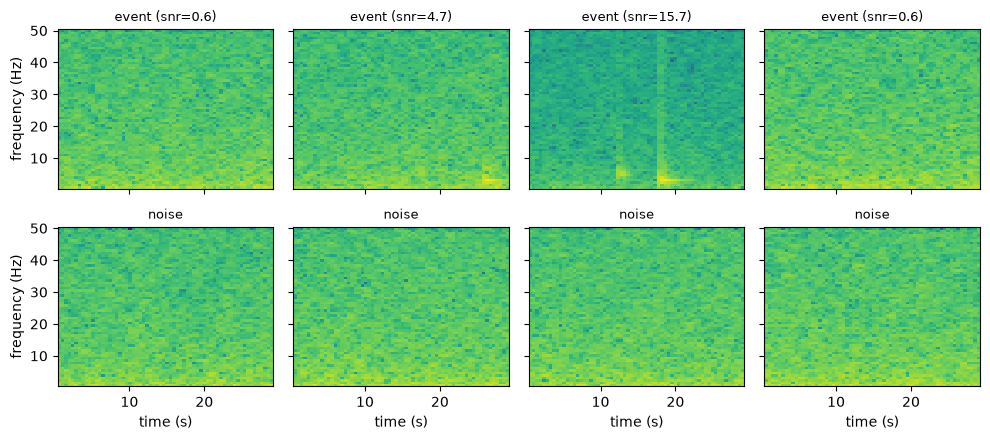

In [3]:
# Show a few spectrograms with their labels
fig, axs = plt.subplots(2, 4, figsize=(10, 4.5), sharex=True, sharey=True)
idx_ev = np.where(y_lab == 1)[0][:4]
idx_no = np.where(y_lab == 0)[0][:4]
for k in range(4):
    axs[0, k].pcolormesh(times, freqs, X_img[idx_ev[k]], cmap="viridis", vmin=0, vmax=1)
    axs[0, k].set_title(f"event (snr={metas[idx_ev[k]]['snr']:.1f})", fontsize=9)
    axs[1, k].pcolormesh(times, freqs, X_img[idx_no[k]], cmap="viridis", vmin=0, vmax=1)
    axs[1, k].set_title("noise", fontsize=9)
for ax in axs[1, :]:
    ax.set_xlabel("time (s)")
for ax in axs[:, 0]:
    ax.set_ylabel("frequency (Hz)")
plt.tight_layout()
plt.show()

Los eventos muestran la firma clásica: un inicio impulsivo, energía concentrada en la frecuencia de esquina de la fuente y una coda que decae con el tiempo. El ruido llena toda la imagen de manera más uniforme. Note que los eventos de baja SNR son difíciles de detectar a simple vista, y ese es justamente el motivo para construir un eliminador de ruido más adelante.

### 1.1 División entrenamiento/validación y cargadores de datos

Dividimos 80/20 y envolvemos las imágenes en `DataLoader`s de PyTorch. Cada cargador entrega pares `(input, target)`. Para un autoencoder simple, el objetivo es la entrada misma.

In [4]:
n = len(X_img)
perm = rng.permutation(n)
n_train = int(0.8 * n)
itrain, ival = perm[:n_train], perm[n_train:]

# Tensors with a channel dimension: (N, 1, 64, 64)
T_train = torch.from_numpy(X_img[itrain]).unsqueeze(1)
T_val = torch.from_numpy(X_img[ival]).unsqueeze(1)
y_train = torch.from_numpy(y_lab[itrain]).long()
y_val = torch.from_numpy(y_lab[ival]).long()

train_loader = DataLoader(TensorDataset(T_train, T_train), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(T_val, T_val), batch_size=64, shuffle=False)

# validation examples used for display: the highest-SNR events, easiest to see
snr_val = np.array([metas[j]["snr"] if y_lab[j] == 1 else 0.0 for j in ival])
disp = torch.from_numpy(np.argsort(snr_val)[::-1][:6].copy())
print("train:", T_train.shape, "| val:", T_val.shape)

train: torch.Size([960, 1, 64, 64]) | val: torch.Size([240, 1, 64, 64])


## 2. Autoencoder denso

El primer autoencoder usa solo capas totalmente conectadas. La imagen de 64x64 se aplana a un vector de 4096 dimensiones, se comprime a un **vector latente de 32 números** (una compresión de 128x) y luego se expande de vuelta. La `Sigmoid` final mantiene la salida en [0, 1], en correspondencia con las imágenes normalizadas.

In [5]:
LATENT = 32

class DenseEncoder(nn.Module):
    def __init__(self, latent=LATENT):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 64, 256), nn.SELU(),
            nn.Linear(256, latent), nn.SELU(),   # bottleneck
        )
    def forward(self, x):
        return self.net(x)

class DenseDecoder(nn.Module):
    def __init__(self, latent=LATENT):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent, 256), nn.SELU(),
            nn.Linear(256, 64 * 64), nn.Sigmoid(),
        )
    def forward(self, x):
        return self.net(x).view(-1, 1, 64, 64)

class AutoEncoder(nn.Module):
    """Generic wrapper: any encoder followed by any decoder."""
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
    def forward(self, x):
        return self.decoder(self.encoder(x))

dense_ae = AutoEncoder(DenseEncoder(), DenseDecoder()).to(device)
summary(dense_ae, input_size=(64, 1, 64, 64), device=device)

Layer (type:depth-idx)                   Output Shape              Param #
AutoEncoder                              [64, 1, 64, 64]           --
├─DenseEncoder: 1-1                      [64, 32]                  --
│    └─Sequential: 2-1                   [64, 32]                  --
│    │    └─Flatten: 3-1                 [64, 4096]                --
│    │    └─Linear: 3-2                  [64, 256]                 1,048,832
│    │    └─SELU: 3-3                    [64, 256]                 --
│    │    └─Linear: 3-4                  [64, 32]                  8,224
│    │    └─SELU: 3-5                    [64, 32]                  --
├─DenseDecoder: 1-2                      [64, 1, 64, 64]           --
│    └─Sequential: 2-2                   [64, 4096]                --
│    │    └─Linear: 3-6                  [64, 256]                 8,448
│    │    └─SELU: 3-7                    [64, 256]                 --
│    │    └─Linear: 3-8                  [64, 4096]                1,052

### 2.1 Función de entrenamiento

Una sola función entrena todos los modelos de este cuaderno. Lee pares `(input, target)` del cargador, así que el mismo código sirve para la reconstrucción simple (objetivo = entrada), la eliminación de ruido (objetivo = imagen limpia) y el enmascaramiento (objetivo = imagen completa). La pérdida es el error cuadrático medio entre la reconstrucción y el objetivo.

In [6]:
def train_ae(model, train_loader, val_loader=None, n_epochs=8, lr=1e-3, print_every=1):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_train = np.zeros(n_epochs)
    loss_val = np.zeros(n_epochs)
    for epoch in range(n_epochs):
        model.train()
        running = 0.0
        for xb, tb in train_loader:
            xb, tb = xb.to(device), tb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), tb)
            loss.backward()
            optimizer.step()
            running += loss.item()
        loss_train[epoch] = running / len(train_loader)
        if val_loader is not None:
            model.eval()
            running = 0.0
            with torch.no_grad():
                for xb, tb in val_loader:
                    xb, tb = xb.to(device), tb.to(device)
                    running += criterion(model(xb), tb).item()
            loss_val[epoch] = running / len(val_loader)
            if (epoch + 1) % print_every == 0:
                print(f"[epoch {epoch+1:2d}] train loss: {loss_train[epoch]:.4f}"
                      f" - val loss: {loss_val[epoch]:.4f}")
        elif (epoch + 1) % print_every == 0:
            print(f"[epoch {epoch+1:2d}] train loss: {loss_train[epoch]:.4f}")
    return loss_train, loss_val

[epoch  1] train loss: 0.0293 - val loss: 0.0054
[epoch  2] train loss: 0.0049 - val loss: 0.0040
[epoch  3] train loss: 0.0039 - val loss: 0.0036


[epoch  4] train loss: 0.0035 - val loss: 0.0034
[epoch  5] train loss: 0.0032 - val loss: 0.0033
[epoch  6] train loss: 0.0032 - val loss: 0.0031


[epoch  7] train loss: 0.0032 - val loss: 0.0032
[epoch  8] train loss: 0.0048 - val loss: 0.0039


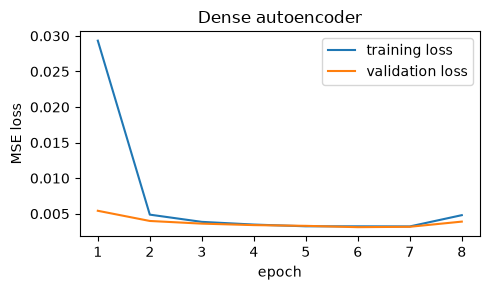

In [7]:
loss_d, loss_dv = train_ae(dense_ae, train_loader, val_loader, n_epochs=8, lr=1e-3)

plt.figure(figsize=(5, 3))
plt.plot(np.arange(1, len(loss_d) + 1), loss_d, label="training loss")
plt.plot(np.arange(1, len(loss_dv) + 1), loss_dv, label="validation loss")
plt.xlabel("epoch"); plt.ylabel("MSE loss"); plt.legend(); plt.title("Dense autoencoder")
plt.tight_layout(); plt.show()

Una nota sobre el cómputo: 8 épocas sobre 960 imágenes pequeñas bastan para ver el comportamiento. En su propia máquina, suba las épocas o el tamaño del conjunto de datos para obtener reconstrucciones más nítidas.

### 2.2 Entrada frente a reconstrucción

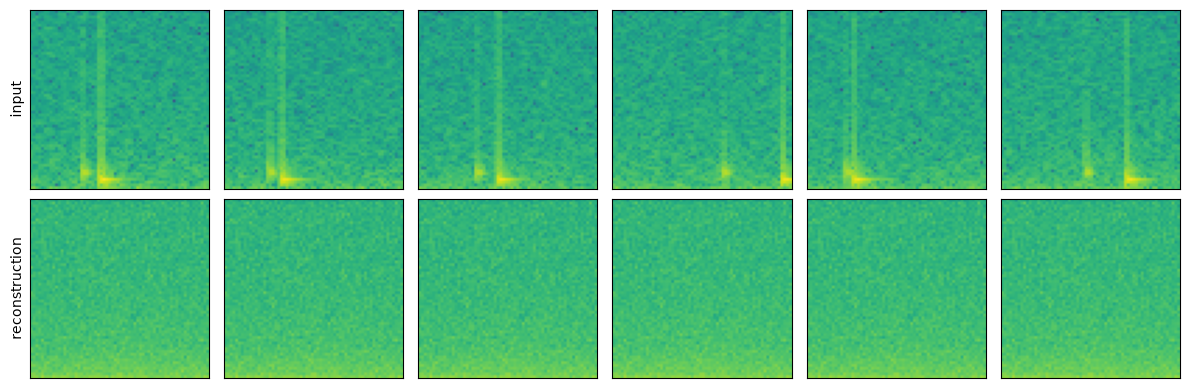

In [8]:
def show_reconstruction(model, inputs, targets=None, n_images=5, row_titles=None):
    """Top row: inputs. Middle (optional): targets. Bottom: model reconstructions."""
    model.eval()
    with torch.no_grad():
        recon = model(inputs[:n_images].to(device)).cpu().numpy().squeeze(1)
    rows = [inputs[:n_images].numpy().squeeze(1), recon]
    if targets is not None:
        rows.append(targets[:n_images].numpy().squeeze(1))
    if row_titles is None:
        row_titles = ["input", "reconstruction", "target"][: len(rows)]
    fig, axs = plt.subplots(len(rows), n_images, figsize=(2 * n_images, 2 * len(rows)))
    for r in range(len(rows)):
        for c in range(n_images):
            axs[r, c].imshow(rows[r][c], origin="lower", cmap="viridis", vmin=0, vmax=1)
            axs[r, c].set_xticks([]); axs[r, c].set_yticks([])
        axs[r, 0].set_ylabel(row_titles[r])
    plt.tight_layout(); plt.show()

show_reconstruction(dense_ae, T_val[disp], n_images=6)

El autoencoder denso reproduce la parte suave de cada imagen, el nivel de fondo y la banda brillante de baja frecuencia, pero las llegadas nítidas desaparecen. Aplanar la imagen tira a la basura la estructura de vecindad 2D, y 32 números latentes no pueden almacenar dónde se ubica una franja vertical delgada.

## 3. Autoencoder convolucional

Las capas convolucionales respetan la estructura 2D del espectrograma. El codificador reduce a la mitad la imagen tres veces con convoluciones con *stride* (paso) (64 -> 32 -> 16 -> 8), y el decodificador lo refleja con capas `ConvTranspose2d`. Agregamos `BatchNorm2d` después de cada convolución, práctica estándar que acelera y estabiliza el entrenamiento.

El cuello de botella es ahora un mapa de características (*feature map*) de 64x8x8. Cuente los números: 4096, los mismos que la entrada. Aquí la compresión es espacial, no en conteo crudo: cada una de las 8x8 posiciones debe resumir un parche de 8x8 de la imagen en 64 características, así que la red sigue sin poder copiar píxeles de un lado al otro. Distintas formas de cuello de botella imponen distintas restricciones, y volvemos a eso más abajo.

In [9]:
class ConvEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1),   # -> 16 x 32 x 32
            nn.BatchNorm2d(16), nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),  # -> 32 x 16 x 16
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),  # -> 64 x 8 x 8
            nn.BatchNorm2d(64), nn.ReLU(),
        )
    def forward(self, x):
        return self.net(x)

class ConvDecoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(16), nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid(),
        )
    def forward(self, x):
        return self.net(x)

conv_ae = AutoEncoder(ConvEncoder(), ConvDecoder()).to(device)
summary(conv_ae, input_size=(64, 1, 64, 64), device=device)

Layer (type:depth-idx)                   Output Shape              Param #
AutoEncoder                              [64, 1, 64, 64]           --
├─ConvEncoder: 1-1                       [64, 64, 8, 8]            --
│    └─Sequential: 2-1                   [64, 64, 8, 8]            --
│    │    └─Conv2d: 3-1                  [64, 16, 32, 32]          160
│    │    └─BatchNorm2d: 3-2             [64, 16, 32, 32]          32
│    │    └─ReLU: 3-3                    [64, 16, 32, 32]          --
│    │    └─Conv2d: 3-4                  [64, 32, 16, 16]          4,640
│    │    └─BatchNorm2d: 3-5             [64, 32, 16, 16]          64
│    │    └─ReLU: 3-6                    [64, 32, 16, 16]          --
│    │    └─Conv2d: 3-7                  [64, 64, 8, 8]            18,496
│    │    └─BatchNorm2d: 3-8             [64, 64, 8, 8]            128
│    │    └─ReLU: 3-9                    [64, 64, 8, 8]            --
├─ConvDecoder: 1-2                       [64, 1, 64, 64]           --
│    └

[epoch  1] train loss: 0.0644 - val loss: 0.0683


[epoch  2] train loss: 0.0327 - val loss: 0.0327


[epoch  3] train loss: 0.0214 - val loss: 0.0190
[epoch  4] train loss: 0.0145 - val loss: 0.0115


[epoch  5] train loss: 0.0100 - val loss: 0.0078
[epoch  6] train loss: 0.0071 - val loss: 0.0059


[epoch  7] train loss: 0.0056 - val loss: 0.0049
[epoch  8] train loss: 0.0046 - val loss: 0.0042


[epoch  9] train loss: 0.0040 - val loss: 0.0037
[epoch 10] train loss: 0.0035 - val loss: 0.0030


[epoch 11] train loss: 0.0030 - val loss: 0.0027
[epoch 12] train loss: 0.0027 - val loss: 0.0026


[epoch 13] train loss: 0.0025 - val loss: 0.0025


[epoch 14] train loss: 0.0024 - val loss: 0.0024
[epoch 15] train loss: 0.0024 - val loss: 0.0024


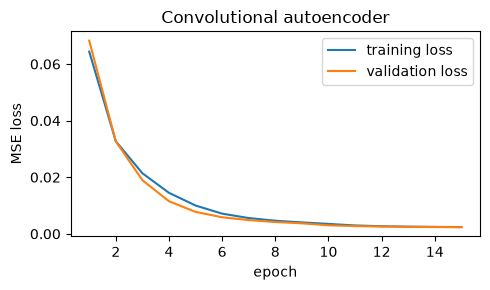

In [10]:
loss_c, loss_cv = train_ae(conv_ae, train_loader, val_loader, n_epochs=15, lr=1e-3)

plt.figure(figsize=(5, 3))
plt.plot(np.arange(1, len(loss_c) + 1), loss_c, label="training loss")
plt.plot(np.arange(1, len(loss_cv) + 1), loss_cv, label="validation loss")
plt.xlabel("epoch"); plt.ylabel("MSE loss"); plt.legend(); plt.title("Convolutional autoencoder")
plt.tight_layout(); plt.show()

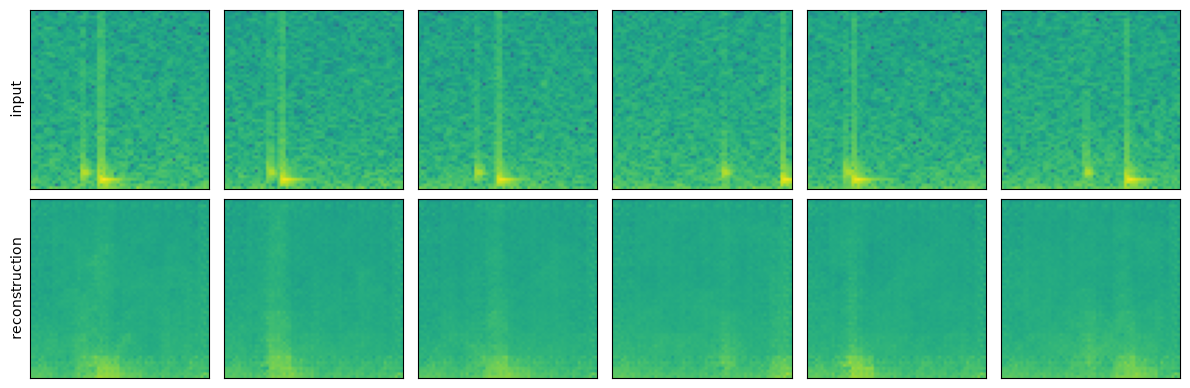

validation MSE  dense: 0.0039   conv: 0.0024


In [11]:
show_reconstruction(conv_ae, T_val[disp], n_images=6)
print(f"validation MSE  dense: {loss_dv[-1]:.4f}   conv: {loss_cv[-1]:.4f}")

El autoencoder convolucional alcanza una pérdida de validación más baja que el denso, y las reconstrucciones ahora conservan un rastro de las llegadas: una franja vertical tenue en la onda S y el parche brillante en el inicio. Siguen siendo borrosas, y eso es inherente a las arquitecturas de cuello de botella: el detalle fino se descarta por diseño.

**El cuello de botella es una perilla, no una elección fija.** El modelo denso exprimió a 32 números, una compresión brutal, y perdió las llegadas. El modelo convolucional conserva 4096 números dispuestos como un mapa espacial grueso, una restricción mucho más suave, lo que explica la salida más nítida. Encoja el cuello de botella y las reconstrucciones se vuelven más borrosas pero la representación se vuelve más abstracta; ensánchelo y la reconstrucción mejora hasta que, en el extremo, la red puede copiar la entrada y no aprende nada útil. El tamaño latente correcto depende de *para qué* quiera usted la representación, idea a la que volvemos en la sección 6. Como ejercicio en casa, agregue una cuarta convolución con *stride* 2 (cuello de botella 128x4x4) o proyecte el mapa de características a un vector de 32 números, reentrene y observe cómo cambia la calidad de la reconstrucción.

## 4. Autoencoder de eliminación de ruido: la recompensa sismológica

Hasta aquí la red reproduce su entrada. Un cambio pequeño la vuelve genuinamente útil: déle un espectrograma **ruidoso** como entrada y el espectrograma **limpio** del mismo evento como objetivo. La red ya no puede aprender la identidad; tiene que aprender cómo se ven las señales de sismos y cómo se ve el ruido, y quedarse solo con las primeras.

Para entrenarla necesitamos pares limpio/ruidoso emparejados, que es exactamente para lo que sirve un generador sintético. `synthetic_seismogram` llamado dos veces con los mismos parámetros de fuente y la misma semilla produce el mismo evento subyacente; solo cambia la amplitud del ruido con `snr`. Usamos `snr=1e6` (ruido un millón de veces menor que la señal, es decir, limpio en la práctica) para el objetivo y un `snr` aleatorio entre 5 y 30 para la entrada: ruidoso, pero con el evento todavía presente en los datos. La celda de abajo verifica el emparejamiento: el residuo entre las dos trazas tiene la amplitud que la SNR predice y no está correlacionado con la señal.

identical source? peak amplitudes: 0.4918 vs 0.4918
residual std: 0.0244 (expected noise std: 0.0264)
correlation of residual with clean signal: +0.004


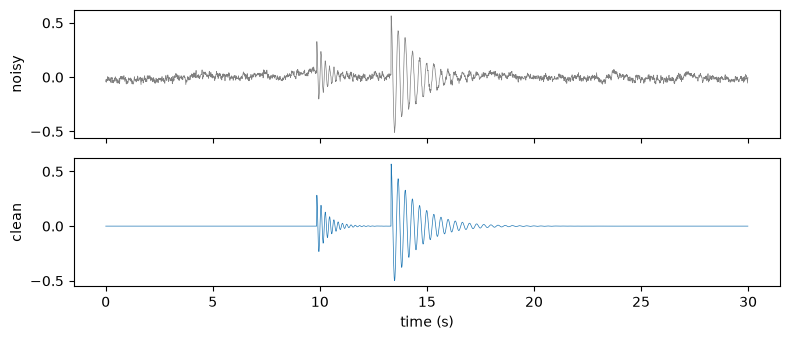

In [12]:
n_pairs = 400
noisy_w = np.zeros((n_pairs, 3000))
clean_w = np.zeros((n_pairs, 3000))
prng = np.random.default_rng(42)
for i in range(n_pairs):
    mag = prng.uniform(1.5, 3.5)
    dist = prng.uniform(5, 60)
    snr_low = 10 ** prng.uniform(np.log10(5.0), np.log10(30.0))   # noisy input
    kw = dict(duration_s=30.0, fs=100.0, magnitude=mag, distance_km=dist, seed=1000 + i)
    _, clean_w[i], mc = synthetic_seismogram(snr=1e6, **kw)
    t, noisy_w[i], mn = synthetic_seismogram(snr=snr_low, **kw)

# Verify: same signal, different noise
resid = noisy_w[0] - clean_w[0]
print(f"identical source? peak amplitudes: {mc['peak_amplitude']:.4f} vs {mn['peak_amplitude']:.4f}")
print(f"residual std: {resid.std():.4f} (expected noise std: {mn['peak_amplitude']/mn['snr']:.4f})")
print(f"correlation of residual with clean signal: {np.corrcoef(resid, clean_w[0])[0, 1]:+.3f}")

fig, axs = plt.subplots(2, 1, figsize=(8, 3.5), sharex=True)
axs[0].plot(t, noisy_w[0], lw=0.5, color="gray"); axs[0].set_ylabel("noisy")
axs[1].plot(t, clean_w[0], lw=0.5, color="C0"); axs[1].set_ylabel("clean")
axs[1].set_xlabel("time (s)")
plt.tight_layout(); plt.show()

In [13]:
# Spectrograms of both, normalized with the SAME global constants as before
S_noisy = np.stack([normalize(log_spectrogram(w)[0]) for w in noisy_w])
S_clean = np.stack([normalize(log_spectrogram(w)[0]) for w in clean_w])

n_tr = int(0.8 * n_pairs)
Tn_train = torch.from_numpy(S_noisy[:n_tr]).unsqueeze(1)
Tc_train = torch.from_numpy(S_clean[:n_tr]).unsqueeze(1)
Tn_val = torch.from_numpy(S_noisy[n_tr:]).unsqueeze(1)
Tc_val = torch.from_numpy(S_clean[n_tr:]).unsqueeze(1)

den_train = DataLoader(TensorDataset(Tn_train, Tc_train), batch_size=64, shuffle=True)
den_val = DataLoader(TensorDataset(Tn_val, Tc_val), batch_size=64, shuffle=False)
print("denoiser training pairs:", len(Tn_train), "| validation pairs:", len(Tn_val))

denoiser training pairs: 320 | validation pairs: 80


La arquitectura no cambia: una instancia nueva del autoencoder convolucional de la sección 3. Solo cambiaron los datos. La tarea es más difícil que la reconstrucción simple, porque ahora la entrada y el objetivo se ven muy distintos, y hay un atajo fácil: producir el fondo oscuro promedio en todas partes. Ese atajo es un mínimo local fuerte (sin normalización por lotes la red se queda atorada en él), así que entrenamos por más tiempo. El modelo es diminuto y cada época toma una fracción de segundo.

In [14]:
denoiser = AutoEncoder(ConvEncoder(), ConvDecoder()).to(device)
loss_n, loss_nv = train_ae(denoiser, den_train, den_val, n_epochs=80, lr=1e-3,
                           print_every=10)

[epoch 10] train loss: 0.0933 - val loss: 0.0891


[epoch 20] train loss: 0.0355 - val loss: 0.0354


[epoch 30] train loss: 0.0208 - val loss: 0.0208


[epoch 40] train loss: 0.0151 - val loss: 0.0157


[epoch 50] train loss: 0.0122 - val loss: 0.0129


[epoch 60] train loss: 0.0102 - val loss: 0.0117


[epoch 70] train loss: 0.0090 - val loss: 0.0109


[epoch 80] train loss: 0.0079 - val loss: 0.0103


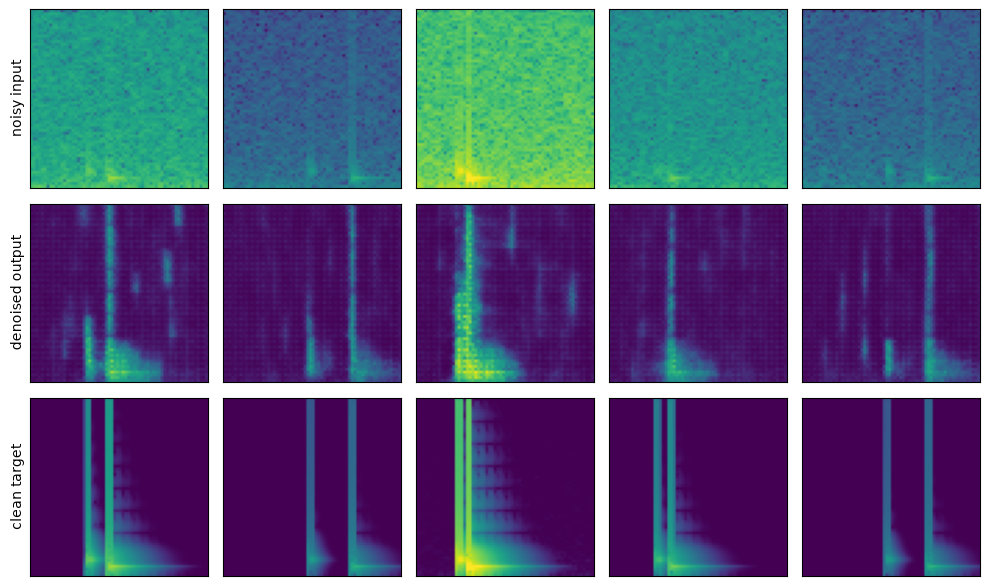

In [15]:
# Noisy input / denoised output / clean target triplets
show_reconstruction(denoiser, Tn_val, targets=Tc_val, n_images=5,
                    row_titles=["noisy input", "denoised output", "clean target"])

El eliminador de ruido suprime el piso de ruido de banda ancha y recupera la energía del evento: la llegada S, la coda, la concentración en baja frecuencia. La salida no es perfecta; las llegadas se difuminan y los ejemplos de baja SNR pierden detalle. Pero recuerde qué es esta red: seis capas convolucionales entrenadas durante 80 épocas sobre 320 pares de imágenes.

Esta miniatura tiene contrapartes directas a escala de investigación. **DeepDenoiser** ([Zhu et al., 2019](https://ieeexplore.ieee.org/abstract/document/8802278)) trabaja sobre la transformada de Fourier de tiempo corto de los sismogramas, exactamente nuestra representación de entrada, y predice máscaras tiempo-frecuencia que separan la señal del ruido; se usa en *pipelines* de monitoreo sísmico en producción. **WaveDecompNet** ([Yin et al., 2022](https://academic.oup.com/gji/article/231/3/1806/6651381)) lleva la idea más lejos con un decodificador de dos ramas que descompone un registro en una componente de sismo y una componente de ruido, conservando ambas, porque el «ruido» (el campo de ondas ambiental) es en sí mismo científicamente útil. Ambas son, en el fondo, redes codificador-decodificador; se diferencian de nuestro juguete en la profundidad, en el tamaño del conjunto de entrenamiento y en las conexiones de salto que se discuten en la sección 7.

## 5. Autoencoder enmascarado: un cambio de diez líneas

Eliminar ruido es una manera de corromper la entrada; **enmascarar** es otra. Ponga en cero parches cuadrados aleatorios de la imagen y pida a la red que reconstruya la imagen completa. Para rellenar un parche faltante, la red no puede copiar píxeles; tiene que entender el contexto, por ejemplo, que la coda de un evento continúa suavemente en el tiempo y que el ruido tiene una forma espectral consistente. El cambio respecto de la sección 3 es de unas diez líneas: una función de enmascaramiento y un nuevo par de cargadores.

In [16]:
def mask_patches(imgs, patch=8, n_patches=12, seed=0):
    """Zero out n_patches random patch x patch squares in each image."""
    g = np.random.default_rng(seed)
    masked = imgs.clone()
    N, _, H, W = imgs.shape
    for i in range(N):
        for _ in range(n_patches):
            r, c = g.integers(0, H - patch), g.integers(0, W - patch)
            masked[i, 0, r:r + patch, c:c + patch] = 0.0
    return masked

M_train = mask_patches(T_train, seed=1)
M_val = mask_patches(T_val, seed=2)
mask_train = DataLoader(TensorDataset(M_train, T_train), batch_size=64, shuffle=True)
mask_val = DataLoader(TensorDataset(M_val, T_val), batch_size=64, shuffle=False)

masked_ae = AutoEncoder(ConvEncoder(), ConvDecoder()).to(device)
loss_m, loss_mv = train_ae(masked_ae, mask_train, mask_val, n_epochs=8, lr=1e-3)

[epoch  1] train loss: 0.0614 - val loss: 0.0478


[epoch  2] train loss: 0.0298 - val loss: 0.0262
[epoch  3] train loss: 0.0167 - val loss: 0.0131


[epoch  4] train loss: 0.0097 - val loss: 0.0071
[epoch  5] train loss: 0.0062 - val loss: 0.0045


[epoch  6] train loss: 0.0044 - val loss: 0.0035


[epoch  7] train loss: 0.0035 - val loss: 0.0031


[epoch  8] train loss: 0.0031 - val loss: 0.0029


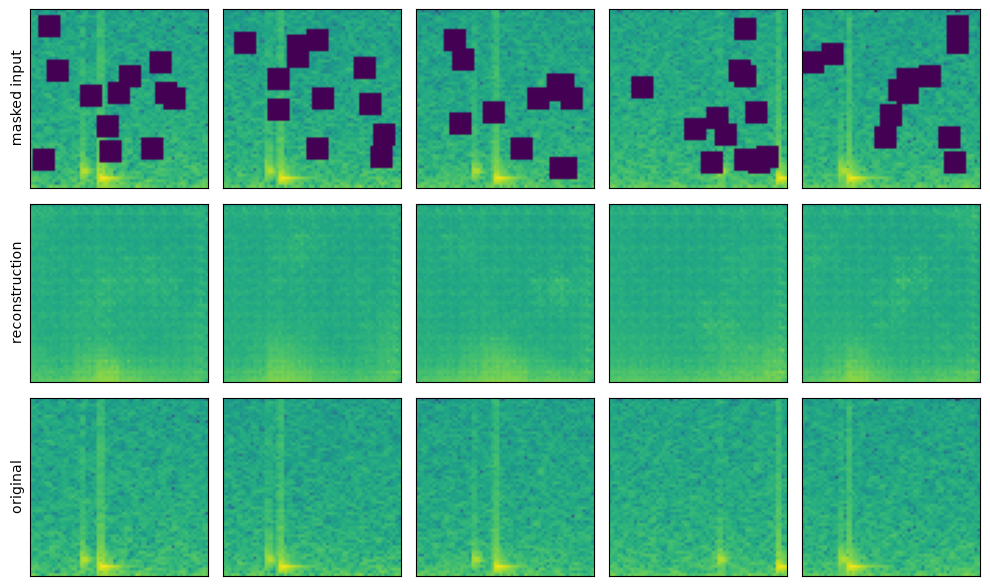

In [17]:
show_reconstruction(masked_ae, M_val[disp], targets=T_val[disp], n_images=5,
                    row_titles=["masked input", "reconstruction", "original"])

Con 12 parches aleatorios de 8x8 ocultos, a lo sumo el 18.75 % de cada imagen de 64x64 (menos donde los parches se solapan), la red rellena los huecos con contenido tiempo-frecuencia verosímil inferido de los alrededores.

Este objetivo, corromper la entrada y predecir lo que se quitó, es el núcleo del **preentrenamiento autosupervisado** moderno. El modelado de lenguaje enmascarado (ocultar palabras y predecirlas) es la forma en que se preentrenan los modelos de lenguaje tipo BERT, y los autoencoders enmascarados para imágenes (He et al., 2022) mostraron que ocultar el 75 % de los parches de una imagen y reconstruirlos produce características que se transfieren bien a clasificación y detección. Ningún ser humano etiquetó nada: los datos se supervisan a sí mismos, así que el preentrenamiento puede consumir archivos sin etiquetar arbitrariamente grandes.

Ese último punto es el motivo por el que esto importa en las geociencias. Las redes sísmicas registran de manera continua y acumulan petabytes de formas de onda sin etiquetar, mientras que los catálogos etiquetados por analistas cubren apenas una rendija de todo eso. Un modelo preentrenado por enmascaramiento o por eliminación de ruido sobre el archivo crudo aprende cómo se ven las señales sísmicas antes de ver una sola etiqueta. Los esfuerzos por construir modelos fundacionales en sismología y en percepción remota siguen exactamente esta receta: preentrenamiento autosupervisado sobre el archivo, y después un ajuste fino supervisado pequeño para cada tarea posterior.

### 5.1 Las mismas diez líneas en un segundo dominio: campos climáticos

Nada del objetivo de enmascaramiento es sismológico. Para demostrarlo, la arquitectura idéntica y las idénticas diez líneas corren en un segundo dominio: los campos de anomalías climáticas en malla del [capítulo 4.3](mlgeo_4.3_CNN.ipynb). Generamos dos campos con `mlgeo_synth.climate_field` (malla de 40 x 80 en latitud-longitud, 30 años de anomalías mensuales) y tratamos el mapa de cada mes como una imagen: 720 imágenes, normalizadas a [0, 1] con constantes globales, exactamente como tratamos los espectrogramas. El autoencoder convolucional es completamente convolucional, así que los mapas de 40 x 80 pasan sin cambiar una línea de código — el cuello de botella es simplemente de 64 x 5 x 10 en lugar de 64 x 8 x 8.

In [18]:
from mlgeo_synth import climate_field

C_maps = np.concatenate([
    climate_field(n_lat=40, n_lon=80, n_months=360, trend_c_per_decade=0.3, seed=sd)[0]
    for sd in (0, 1)]).astype(np.float32)          # (720, 40, 80) monthly anomaly maps
C_imgs = ((C_maps - C_maps.min()) / (C_maps.max() - C_maps.min())).astype(np.float32)

perm_c = np.random.default_rng(7).permutation(len(C_imgs))
n_ct = int(0.8 * len(C_imgs))
Ct_train = torch.from_numpy(C_imgs[perm_c[:n_ct]]).unsqueeze(1)
Ct_val = torch.from_numpy(C_imgs[perm_c[n_ct:]]).unsqueeze(1)

Cm_train, Cm_val = mask_patches(Ct_train, seed=3), mask_patches(Ct_val, seed=4)
cmask_train = DataLoader(TensorDataset(Cm_train, Ct_train), batch_size=64, shuffle=True)
cmask_val = DataLoader(TensorDataset(Cm_val, Ct_val), batch_size=64, shuffle=False)

masked_ae_clim = AutoEncoder(ConvEncoder(), ConvDecoder()).to(device)
loss_mc, loss_mcv = train_ae(masked_ae_clim, cmask_train, cmask_val, n_epochs=8, lr=1e-3)

[epoch  1] train loss: 0.0517 - val loss: 0.0481
[epoch  2] train loss: 0.0297 - val loss: 0.0468
[epoch  3] train loss: 0.0199 - val loss: 0.0456


[epoch  4] train loss: 0.0119 - val loss: 0.0320
[epoch  5] train loss: 0.0068 - val loss: 0.0098


[epoch  6] train loss: 0.0040 - val loss: 0.0045
[epoch  7] train loss: 0.0027 - val loss: 0.0023


[epoch  8] train loss: 0.0020 - val loss: 0.0021


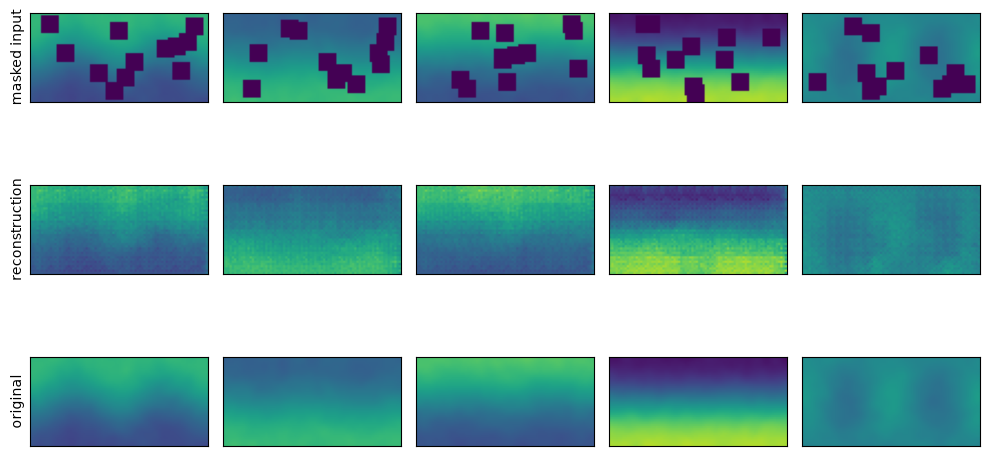

In [19]:
show_reconstruction(masked_ae_clim, Cm_val[:5], targets=Ct_val[:5], n_images=5,
                    row_titles=["masked input", "reconstruction", "original"])

La red rellena los cuadros enmascarados con una estructura de anomalías suave y consistente en latitud, y termina cerca de un MSE de validación de 0.002 en este dominio: las bandas estacionales y el patrón zonal le dan un contexto fuerte del cual inferir. Una arquitectura, un objetivo, dos dominios de las ciencias de la Tierra — esa portabilidad, y no ninguna reconstrucción en particular, es el argumento a favor del preentrenamiento autosupervisado sobre archivos en malla, y es exactamente la receta detrás de los modelos fundacionales de percepción remota y de meteorología.

## 6. El codificador es lo que se reutiliza

Después del entrenamiento, el decodificador suele desecharse. El artefacto valioso es el **codificador**: un extractor de características aprendido sin etiquetas. Aquí está la prueba. El codificador del autoencoder convolucional de la sección 3 fue entrenado solo con reconstrucción; nunca vio una etiqueta de evento/ruido. Primero miramos su espacio latente y luego lo usamos para clasificar con muy pocas etiquetas.

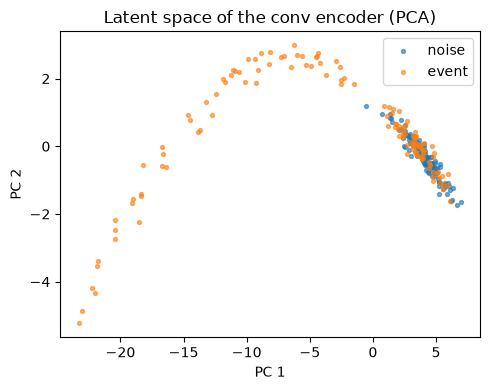

In [20]:
# PCA of the frozen encoder's latent space, colored by (held-out) labels
from sklearn.decomposition import PCA

conv_ae.eval()
with torch.no_grad():
    Z_val = conv_ae.encoder(T_val.to(device)).flatten(1).cpu().numpy()
Z2 = PCA(n_components=2).fit_transform(Z_val)

plt.figure(figsize=(5, 4))
for lab, name, col in [(0, "noise", "C0"), (1, "event", "C1")]:
    m = y_val.numpy() == lab
    plt.scatter(Z2[m, 0], Z2[m, 1], s=8, c=col, label=name, alpha=0.6)
plt.xlabel("PC 1"); plt.ylabel("PC 2"); plt.legend()
plt.title("Latent space of the conv encoder (PCA)")
plt.tight_layout(); plt.show()

Las dos clases ya se separan, al menos en parte, aunque no se haya usado ninguna etiqueta en el entrenamiento. Ahora el experimento: suponga que un analista etiquetó solo el **10 % del conjunto de entrenamiento** (96 espectrogramas). Comparamos dos clasificadores con la arquitectura idéntica, codificador + cabeza lineal pequeña, entrenados sobre esos mismos 96 ejemplos etiquetados:

1. **Sonda lineal:** el codificador preentrenado, congelado; solo entrena la cabeza. (Esto es *sondeo*, no ajuste fino: el ajuste fino también actualizaría los pesos del codificador, mientras que una sonda los mantiene fijos y mide lo que las características preentrenadas cargan por sí solas.)
2. **Desde cero:** un codificador y una cabeza inicializados al azar, todo entrenado.

La cabeza es una sola capa lineal precedida por un `BatchNorm1d` que estandariza las 4096 características del codificador; sin esa estandarización, una sonda lineal entrena mal sobre activaciones ReLU crudas. Una sutileza: un codificador congelado que contiene capas de normalización por lotes debe permanecer en modo `eval()` durante el entrenamiento, porque de lo contrario sus estadísticas móviles siguen actualizándose aunque sus pesos estén congelados. Sobrescribimos `train()` para forzarlo. Ambos clasificadores reciben la cabeza idéntica y el presupuesto de entrenamiento idéntico, así que la única diferencia es de dónde vienen los pesos del codificador.

In [21]:
import copy

# 10% of the training labels
n_lab = int(0.10 * len(T_train))
lab_idx = torch.randperm(len(T_train), generator=torch.Generator().manual_seed(3))[:n_lab]
X_lab, y_lab_small = T_train[lab_idx], y_train[lab_idx]
print(f"labeled examples: {n_lab} ({int(y_lab_small.sum())} events, {n_lab - int(y_lab_small.sum())} noise)")
lab_loader = DataLoader(TensorDataset(X_lab, y_lab_small), batch_size=32, shuffle=True)

class EncoderClassifier(nn.Module):
    def __init__(self, encoder, freeze=False):
        super().__init__()
        self.encoder = encoder
        self.frozen = freeze
        if freeze:
            for p in self.encoder.parameters():
                p.requires_grad = False
        self.head = nn.Sequential(nn.Flatten(),
                                  nn.BatchNorm1d(64 * 8 * 8),
                                  nn.Linear(64 * 8 * 8, 2))
    def train(self, mode=True):
        super().train(mode)
        if self.frozen:
            self.encoder.eval()   # frozen batch-norm stats stay fixed
        return self
    def forward(self, x):
        return self.head(self.encoder(x))

def train_classifier(model, loader, n_epochs=30, lr=1e-3, X_eval=None, y_eval=None):
    if X_eval is None:
        X_eval, y_eval = T_val, y_val
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=lr)
    acc_hist = np.zeros(n_epochs)
    for epoch in range(n_epochs):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
        model.eval()
        with torch.no_grad():
            pred = model(X_eval.to(device)).argmax(1).cpu()
        acc_hist[epoch] = (pred == y_eval).float().mean().item()
    return acc_hist

# 1) linear probe: frozen pretrained encoder + trainable head
torch.manual_seed(5)
probe = EncoderClassifier(copy.deepcopy(conv_ae.encoder), freeze=True).to(device)
acc_probe = train_classifier(probe, lab_loader)

# 2) same architecture from scratch on the same 96 examples
torch.manual_seed(5)
scratch = EncoderClassifier(ConvEncoder(), freeze=False).to(device)
acc_sc = train_classifier(scratch, lab_loader)

print(f"final validation accuracy  linear probe: {acc_probe[-1]:.3f}   from scratch: {acc_sc[-1]:.3f}")

labeled examples: 96 (45 events, 51 noise)


final validation accuracy  linear probe: 0.725   from scratch: 0.721


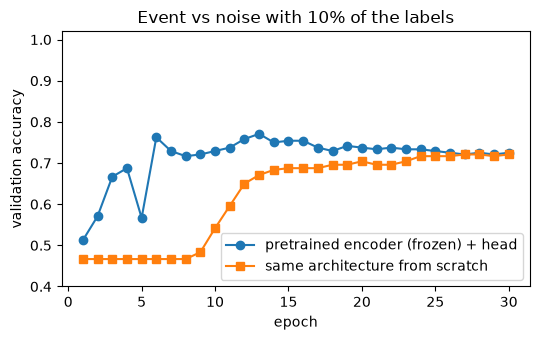

In [22]:
plt.figure(figsize=(5.5, 3.5))
ep = np.arange(1, len(acc_probe) + 1)
plt.plot(ep, acc_probe, "o-", label="pretrained encoder (frozen) + head")
plt.plot(ep, acc_sc, "s-", label="same architecture from scratch")
plt.xlabel("epoch"); plt.ylabel("validation accuracy")
plt.title("Event vs noise with 10% of the labels")
plt.legend(loc="lower right"); plt.ylim(0.4, 1.02)
plt.tight_layout(); plt.show()

Lea las curvas de izquierda a derecha. El codificador preentrenado es útil desde la primera época: sus características ya organizan los datos, así que la cabeza alcanza su meseta casi de inmediato. El modelo desde cero gasta la mayor parte de su presupuesto al nivel del azar mientras aprende filtros convolucionales a partir de solo 96 ejemplos, luego sube y, en esta tarea pequeña, al final se acerca. Esa trayectoria es lo importante: con preentrenamiento usted paga una sola vez por el aprendizaje de características, con datos sin etiquetar, en lugar de volver a pagarlo en cada tarea con etiquetas escasas. Los números exactos varían de corrida a corrida; la brecha de las primeras épocas se ensancha a medida que las etiquetas escasean o los modelos crecen. Pruebe con el 5 % o el 2 % de las etiquetas en su propia máquina.

Este es el argumento práctico a favor del aprendizaje autosupervisado. Los objetivos de reconstrucción, de eliminación de ruido y de enmascaramiento extraen estructura de datos *sin etiquetar*, y los datos sin etiquetar son lo que las geociencias tienen en abundancia. El recurso caro, las etiquetas expertas, se gasta entonces solo en un conjunto etiquetado pequeño, ya sea a través de una sonda lineal como aquí o a través de un ajuste fino completo que también actualice el codificador. Cuando lea sobre modelos fundacionales preentrenados sobre archivos sísmicos continuos o pilas de imágenes satelitales, esta receta de dos etapas, preentrenamiento autosupervisado seguido de una adaptación supervisada ligera, es a lo que se refieren.

### 6.1 ¿Sobrevive el codificador a los datos reales? Una sonda de transferencia con miniPNW

La sonda de arriba es sintético-a-sintético: un codificador preentrenado sobre espectrogramas sintéticos, sondeado con etiquetas sintéticas y calificado sobre datos de validación sintéticos. El [capítulo 4.3](mlgeo_4.3_CNN.ipynb) mostró qué ocurre cuando un *clasificador* entrenado con sintéticos se encuentra con formas de onda reales: colapsa al nivel del azar. La pregunta autosupervisada es más sutil y más esperanzadora: aunque el clasificador muera, ¿las *características* preentrenadas cargan algo a través de la brecha?

La prueba: construir espectrogramas reales a partir de las formas de onda etiquetadas de **miniPNW** que el [capítulo 2.11](../Chapter2-DataManipulation/2.11_feature_engineering.ipynb) dejó en caché ([Ni et al., 2023](https://doi.org/10.26443/seismica.v2i1.368)) — 300 ventanas reales de sismos (el *pick* de P a los 7 s dentro de una ventana de 30 s) y 300 ventanas de ruido previo al evento, cada una normalizada a pico unitario igual que las formas de onda sintéticas, y luego pasadas por el mismo *pipeline* de espectrogramas con la misma normalización global. Después entrenamos la sonda lineal idéntica — el codificador congelado preentrenado con sintéticos más una cabeza nueva — sobre 96 ejemplos etiquetados *reales*, el mismo presupuesto de etiquetas del 10 % que antes, y evaluamos sobre un conjunto de prueba reservado de ventanas reales. La exactitud sintético-a-sintético aparece al lado para comparación directa.

In [23]:
import urllib.request
import h5py
import pandas as pd

# Same files and loader pattern as notebook 2.11, which caches them in its data/ folder
pnw_dir = os.path.join('..', 'Chapter2-DataManipulation', 'data')
os.makedirs(pnw_dir, exist_ok=True)
metadata_path = os.path.join(pnw_dir, 'miniPNW_metadata.csv')
waveform_path = os.path.join(pnw_dir, 'miniPNW_waveforms.hdf5')
base_url = 'https://dasway.ess.washington.edu/shared/niyiyu/PNW-ML'

have_pnw = True
try:
    if not os.path.exists(metadata_path):
        urllib.request.urlretrieve(f'{base_url}/miniPNW_metadata.csv', metadata_path)
    if not os.path.exists(waveform_path):
        print('Downloading miniPNW waveforms (about 670 MB, one-time; shared with notebook 2.11)...')
        urllib.request.urlretrieve(f'{base_url}/miniPNW_waveforms.hdf5', waveform_path)
except Exception as err:
    have_pnw = False
    print('miniPNW cache is missing and the download failed, so the transfer probe below is skipped.\n'
          'Run notebook 2.11 first (it downloads and caches the files), then rerun this section.\n'
          f'Reason: {err!r}')
have_pnw = have_pnw and os.path.exists(waveform_path)
print('miniPNW available:', have_pnw)

miniPNW available: True


In [24]:
if have_pnw:
    meta = pd.read_csv(metadata_path)
    eq = meta[(meta['source_type'] == 'earthquake') & meta['trace_P_arrival_sample'].notna()].copy()
    n_win, pre = 3000, 700  # 30 s at 100 Hz, P pick 7 s into the window
    p_samp = eq['trace_P_arrival_sample'].astype(int)
    eq = eq[(p_samp - pre >= n_win) & (p_samp - pre + n_win <= 15001)].head(300)

    def read_z(f, trace_name):
        """Vertical component of one miniPNW trace (same reader as notebook 2.11)."""
        bucket, narray = trace_name.split('$')
        x, _, z = (int(v) for v in narray.split(',:'))
        return f['/data/' + bucket][x, 2, :z]  # channel order N, E, Z

    R_ev = np.zeros((len(eq), n_win))
    R_no = np.zeros((len(eq), n_win))
    with h5py.File(waveform_path, 'r') as f:
        for i, (_, row) in enumerate(eq.iterrows()):
            tr = read_z(f, row['trace_name']).astype(np.float64)
            pk = int(row['trace_P_arrival_sample'])
            R_ev[i] = tr[pk - pre : pk - pre + n_win]
            R_no[i] = tr[:n_win]  # the trace starts 50 s before the pick: pre-event noise

    R_wave = np.concatenate([R_ev, R_no])
    yR = np.concatenate([np.ones(len(R_ev)), np.zeros(len(R_no))]).astype(int)
    alive = R_wave.std(axis=1) > 0
    R_wave, yR = R_wave[alive], yR[alive]
    R_wave = R_wave - R_wave.mean(axis=1, keepdims=True)
    R_wave = R_wave / np.abs(R_wave).max(axis=1, keepdims=True)  # unit peak, like the synthetics

    # identical spectrogram pipeline, identical global normalization constants
    R_spec = np.stack([normalize(log_spectrogram(w)[0]) for w in R_wave])
    perm_r = np.random.default_rng(11).permutation(len(R_spec))
    n_rt = int(0.8 * len(R_spec))
    TR_train = torch.from_numpy(R_spec[perm_r[:n_rt]]).unsqueeze(1)
    TR_val = torch.from_numpy(R_spec[perm_r[n_rt:]]).unsqueeze(1)
    yR_train = torch.from_numpy(yR[perm_r[:n_rt]]).long()
    yR_val = torch.from_numpy(yR[perm_r[n_rt:]]).long()
    print(f"real spectrograms: {len(R_spec)} ({int(yR.sum())} earthquake, {int((1 - yR).sum())} noise)"
          f" | train {len(TR_train)}, val {len(TR_val)}")

real spectrograms: 600 (300 earthquake, 300 noise) | train 480, val 120


linear probe on synthetic val (synthetic labels):  0.725
linear probe on real miniPNW val (real labels):    0.908
synthetic-to-real transfer gap:                    -0.183
zero-shot (synthetic-label probe on real val):     0.633


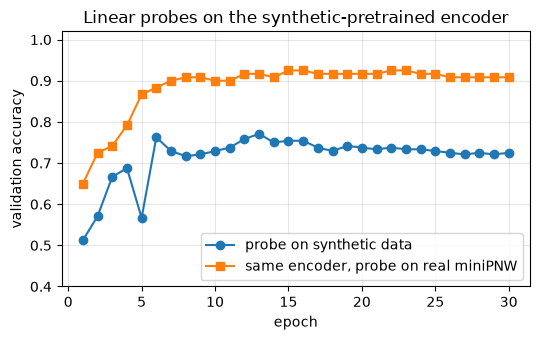

In [25]:
if have_pnw:
    # same 10% label budget as the synthetic probe: 96 real labeled examples
    lab_r = torch.randperm(len(TR_train), generator=torch.Generator().manual_seed(3))[:n_lab]
    real_lab_loader = DataLoader(TensorDataset(TR_train[lab_r], yR_train[lab_r]),
                                 batch_size=32, shuffle=True)

    torch.manual_seed(5)
    probe_real = EncoderClassifier(copy.deepcopy(conv_ae.encoder), freeze=True).to(device)
    acc_real = train_classifier(probe_real, real_lab_loader, X_eval=TR_val, y_eval=yR_val)

    # zero-shot for reference: the probe trained on synthetic labels, applied to real data
    probe.eval()
    with torch.no_grad():
        zeroshot = (probe(TR_val.to(device)).argmax(1).cpu() == yR_val).float().mean().item()

    print(f"linear probe on synthetic val (synthetic labels):  {acc_probe[-1]:.3f}")
    print(f"linear probe on real miniPNW val (real labels):    {acc_real[-1]:.3f}")
    print(f"synthetic-to-real transfer gap:                    {acc_probe[-1] - acc_real[-1]:.3f}")
    print(f"zero-shot (synthetic-label probe on real val):     {zeroshot:.3f}")

    plt.figure(figsize=(5.5, 3.5))
    ep = np.arange(1, len(acc_probe) + 1)
    plt.plot(ep, acc_probe, "o-", label="probe on synthetic data")
    plt.plot(ep, acc_real, "s-", label="same encoder, probe on real miniPNW")
    plt.xlabel("epoch"); plt.ylabel("validation accuracy")
    plt.title("Linear probes on the synthetic-pretrained encoder")
    plt.legend(loc="lower right"); plt.ylim(0.4, 1.02)
    plt.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

Tres números para leer juntos, y un signo que puede sorprender. La sonda sintético-a-sintético queda en 72.5 %. El mismo codificador congelado, sondeado con 96 etiquetas reales, alcanza 90.8 % sobre ventanas reales de miniPNW — la «brecha» de transferencia es negativa, -18 puntos. Eso no significa que el preentrenamiento sintético le gane a los datos reales; significa que las dos tareas no son igual de difíciles. El conjunto de validación sintético incluye a propósito eventos hasta SNR 0.5, muchos de ellos irreductiblemente indetectables, mientras que los sismos de miniPNW fueron marcados por analistas y en su mayoría son claros, y el ruido real previo al evento es espectralmente distintivo. Las conclusiones honestas son las relativas. Primero, el modo *zero-shot* (sin ningún ejemplo etiquetado de la tarea) falla: la cabeza entrenada con etiquetas sintéticas logra 63.3 % sobre ventanas reales, haciendo eco del colapso del clasificador entrenado con sintéticos en [4.3](mlgeo_4.3_CNN.ipynb) — las fronteras de decisión no se transfieren. Segundo, las características que están debajo sí se transfieren: sin actualizar un solo peso del codificador con datos reales, 96 etiquetas reales bastan para llegar al 91 %. Esa asimetría es el argumento práctico a favor del preentrenamiento autosupervisado — las representaciones sobreviven a un cambio de dominio que los clasificadores no sobreviven, y el precio de cruzarlo es de cien etiquetas, no de una red reentrenada.

## 7. Más allá del cuello de botella: conexiones de salto y U-Nets

Nuestras reconstrucciones son borrosas porque todo debe pasar por un cuello de botella de baja dimensión, que descarta el detalle fino por diseño. El arreglo estándar es la **conexión de salto** (*skip connection*): alimentar la salida de cada etapa del codificador directamente a la etapa correspondiente del decodificador, para que el detalle de alta resolución evite el cuello de botella mientras la vía profunda carga el contexto. Un codificador-decodificador con conexiones de salto en todos los niveles es una **U-Net** (Ronneberger et al., 2015), el caballo de batalla de la segmentación de imágenes y de la mayoría de los modelos de aprendizaje profundo en sismología.

![Unet](../img/Unet.png)

DeepDenoiser y WaveDecompNet, de la sección 4, usan ambos conexiones de salto, y los marcadores de fases como PhaseNet son U-Nets aplicadas a formas de onda. Los codificadores-decodificadores multitarea llevan la idea más lejos: el Earthquake Transformer ([Mousavi et al., 2020](https://www.nature.com/articles/s41467-020-17591-w)) decodifica probabilidades de detección, de *pick* de P y de *pick* de S a partir de un solo codificador. Aquí no implementamos U-Nets; el punto es que son autoencoders más atajos.

## Resumen

* Un autoencoder aprende una representación latente compacta reconstruyendo su propia entrada; no hacen falta etiquetas.
* Los autoencoders convolucionales superan a los densos en datos con forma de imagen, como los espectrogramas.
* Cambiar el *objetivo* convierte la reconstrucción en algo útil: espectrogramas limpios dan un eliminador de ruido (la miniatura de DeepDenoiser y WaveDecompNet); reconstruir parches enmascarados da el objetivo detrás del preentrenamiento enmascarado moderno.
* El codificador entrenado es el producto reutilizable: congelado detrás de una sonda lineal entrenada con el 10 % de las etiquetas, alcanzó su meseta de exactitud en unas pocas épocas, mientras que la misma arquitectura entrenada desde cero gastó la mayor parte de su presupuesto reaprendiendo características.
* El objetivo de enmascaramiento se portó a un segundo dominio — mapas mensuales de anomalías climáticas — sin más cambio que un nuevo cargador de datos; la portabilidad entre dominios es el sentido de la autosupervisión.
* Sondeado sobre espectrogramas reales de miniPNW, el codificador congelado preentrenado con sintéticos sostiene una exactitud del 90.8 % a partir de 96 etiquetas reales, mientras que la cabeza con etiquetas sintéticas transfiere apenas al 63.3 %: las características cruzan la brecha sintético-real, las fronteras de decisión no.

A continuación: redes neuronales informadas por la física, donde la función de pérdida misma codifica las ecuaciones de gobierno.